# $\Psi(2S)$ discovery with CMS data
#### Gabriele Radano, Matteo Bellino - Spring semester 2025

# 0. Importing packages

In [1]:
# Importing packages
import pickle as pkl                 # Needed to import the pkl files
import numpy  as np
import math                          # Needed to check if the bNLL is NaN (negative number inside the logarithm)
import matplotlib.pyplot as plt
import seaborn as sns
import lmfit                         # Package to minimize functions (it is more well-structured than scipy.optimize)
from dataclasses import dataclass
from scipy.integrate import quad     # Numerical integral evaluation, useful to compute the integral of the model inside the bin
import sys                           # Needed to know what's the highest float value accepted
from collections.abc import Iterable # Needed to check inside crystall_ball if we are giving an array or a float
import tensorflow as tf
import zfit
from zfit import z  # math backend of zfit
import zfit.z.numpy as znp
import os
import mplhep
from scipy.stats import chi2
from scipy.stats import ks_1samp
from hepstats.hypotests import UpperLimit
from hepstats.hypotests.parameters import POIarray
from hepstats.hypotests.parameters import POI
from hepstats.hypotests.calculators import AsymptoticCalculator, FrequentistCalculator
from hepstats.hypotests import Discovery
from utils import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import ScalarFormatter
from hepstats.hypotests import Discovery
import winsound

C:\Users\Gabriele\anaconda3\envs\env_Project\lib\site-packages\zfit\__init__.py:60: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


# 1. Loading data

We can cut if we have high stats becuase it is clear that THERE IS a signal, thus we are interested only in fitting the two crystall balls/gaussian in the best way possible.
The extra background does not add useful infromation to the fit. Furthermore the background model has no physical justification and we just want the model to fit the bkg well.
In the case of low statistics, we are interested in setting an upper limit to the cross-section of psi2s, and in the computation of $CL_b$ the shape of the background is more relevant, so we keep the entire window.

In [2]:
mass_cut_HS = 4.5
mass_cut_LS = 4.5
fs = '15'
tfs = 13

In [3]:
# Importing data from files
with open('DataSet.pkl', 'rb') as file: # The 'rb' stands for 'read binary', necessary for this kind of file
    data_HS = pkl.load(file)            # Data with High Statistics 
data_HS = data_HS[data_HS<mass_cut_HS]

with open('DataSet_lowstat.pkl', 'rb') as file:
    data_LS = pkl.load(file)            # Data with Low Statistics
data_LS = data_LS[data_LS<mass_cut_LS]

Bin number: 77


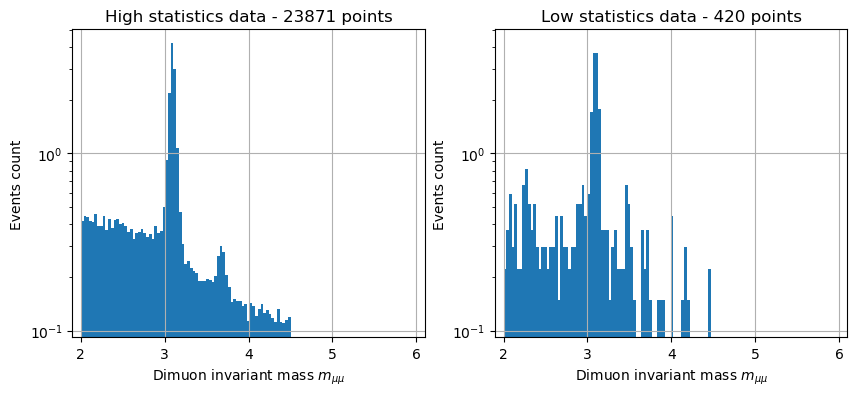

In [4]:
# Plotting raw data
normalize = True
scale     = 'log'
bin_num   = int(np.sqrt(len(data_HS))/2)
print(f'Bin number: {bin_num}')
fig, axes = plt.subplots(1,2, figsize=(10,4))

ax = axes[0]
ax.grid(1)
ax.hist(data_HS, density=normalize, bins=bin_num)
ax.set_title(f'High statistics data - {len(data_HS)} points')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_yscale(scale)
ylim = ax.set_ylim()

ax = axes[1]
ax.grid(1)
ax.hist(data_LS, density=normalize, bins=int(bin_num))
ax.set_title(f'Low statistics data - {len(data_LS)} points')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_ylim(ylim)
ax.set_yscale(scale)
plt.show()

# 2. Defining the model

## 2.1. Bare background

We want to use chebyshev polynomials to model the bare bkg, excluding the resonance of the J/$\Psi$ and the signal we are looking for of the $\Psi$(2S) we need to perform the following operations:
1. Make the polynomials positive:
   add 1 to each element of the polynomial
2. Normalize the polynomial in $[-1,1]$ (can be done analytically)
3. Take a linear combination and normalize the sum in $[-1,1]$ (one could simply normalize at the end)  

At this point one gets the following result:
\begin{equation}
    f(x) = \{a_3 \cdot \frac{(4x^3-3x +1)}{2} + a_2\cdot\frac{3x^2}{2} + a_1\cdot \frac{x+1}{2} + a_0\frac{1}{2}\} / {\sum a_i}
\end{equation}
However, we want to describe a pdf in the interval $[2,6]$, therefore we must perform a change of variable. Given z in $[2,6]$:
\begin{equation}
    x = -1 + 2 \frac{z-2}{6-2} \in [-1,1]
\end{equation}

**Watch out!**
Since probability/normalization must be conserved and we changed the measure, the pdf obtained applying the change of vairable must be divided by $dx/dz = 2$.

## 2.2. J/$\Psi$ and $\Psi(2S)$ resonances

We model the peak of the J/$\Psi$ resonance with a crystal ball distribution, which is conceived to describe the invariant mass distribution in the presence of energy losses (brehmstralung radiation). In our case, we are interested at a one-sided crystall ball, with the polynomial tail to the left (lower invariant masses due to energy loss). The distribution is a piecewise function, which turns to a polynomial at a certain point:
\begin{equation}
    f(x) = N\cdot\begin{cases}
    e^{-\frac{(x-\mu)^2}{2\sigma^2}} \qquad\qquad\qquad \frac{x-\mu}{\sigma}>-\alpha\\
    A\cdot(B-\frac{x-\mu}{\sigma})^{-n} \qquad \frac{x-\mu}{\sigma}<-\alpha
    \end{cases}
\end{equation}
The parameters $A, B$ are known, the factor N ensures proper normalization.

## 2.3. Combined model

Combining the three features we observe in the invariant mass spectrum may result in a big mess if not handled properly. Here we describe how we intend to tackle the problem. First, a rescaled-pdf will be defined *combined_model*: it will be obtained as

$$combined\_model(x) = \text{N}_\text{bkg}\cdot cheb3r(x) + \text{N}_\text{JPsi}\cdot crystal\_ball(x) + \text{N}_\text{Psi2S}\cdot crystal\_ball(x)$$

where each pdf is multiplied by the corresponding yield (the number of events expected for bkg, JPsi and Psi2S). Since each constituting pdf is normalized, the integral of this combined model is the total number of expected events. Keep in mind that the yield of the Psi2S resonance is expressed in terms of the cross section of the process as follows

$$\text{N}_{Psi2S} = 0.75 \cdot 37 \cdot \text{cross\_section}$$

where the efficiency (0.75) and the luminosity (37 inverse pb) are fixed and the cross section is expressed in pb. The other yields are simple optimization parameters.

This function is ready to be integrated inside each bin to provide the number of events the model predicts inside that bin. This integration will be performed by another function that will simply integrate combined_model inside the bins.

In [5]:
#Parameters and observables
obs = zfit.Space('mass', limits=(2.0, mass_cut_HS))  # GeV
eps_uu = 0.75
lumi = 37

# Background parameters
a1 = zfit.Parameter("a1", -0.7, -2, 2)
a2 = zfit.Parameter("a2", 0.3, -2, 2)
a3 = zfit.Parameter("a3", -0.03, -2, 2)
yield_bkg = zfit.Parameter("yield_bkg", 18000, 0, 50000)

bkg = zfit.pdf.Chebyshev(obs=obs, coeffs=[a1, a2, a3])
bkg_ext = bkg.create_extended(yield_bkg)

# J/ψ Crystal Ball parameters
mu_jpsi = zfit.Parameter("mu_jpsi", 3.1, 3.0, 3.2)
sigma_cb_jpsi = zfit.Parameter("sigma_cb_jpsi", 0.03, 0.01, 0.1)
sigma_g_jpsi = zfit.Parameter("sigma_g_jpsi", 0.03, 0.01, 0.1)
alpha_jpsi = zfit.Parameter("alpha_jpsi", 1.5, -5, 5)
n_jpsi = zfit.Parameter("n_jpsi", 1.5, 0.2, 10)

yield_cb_jpsi = zfit.Parameter("yield_cb_jpsi", 1500.0, 0.0, 10000.0)
yield_g_jpsi = zfit.Parameter("yield_g_jpsi", 1500.0, 0.0, 10000.0)

cb_jpsi     = zfit.pdf.CrystalBall(obs=obs, mu=mu_jpsi, sigma=sigma_cb_jpsi, alpha=alpha_jpsi, n=n_jpsi) 
cb_jpsi_ext = cb_jpsi.create_extended(yield_cb_jpsi)
g_jpsi     = zfit.pdf.Gauss(obs=obs, mu=mu_jpsi, sigma=sigma_g_jpsi)
g_jpsi_ext = g_jpsi.create_extended(yield_g_jpsi) #modified, here was used a function that does not exist anymore
total_jpsi_ext = zfit.pdf.SumPDF([cb_jpsi_ext, g_jpsi_ext])

# Psi(2S) Crystal Ball parameters
mu_psi2s = zfit.Parameter("mu_psi2s", 3.7, 3.6, 3.8)
sigma_psi2s = zfit.Parameter("sigma_psi2s", 0.03, 0.01, 0.1)
xs_psi2s = zfit.Parameter("xs_psi2s", 3., 0.0, 40.0)
yield_psi2s = zfit.ComposedParameter("yield_psi2s", lambda xs: eps_uu * lumi * xs, params=[xs_psi2s])

g_psi2s = zfit.pdf.Gauss(obs=obs, mu=mu_psi2s, sigma=sigma_psi2s)
g_psi2s_ext = g_psi2s.create_extended(yield_psi2s)

#Total model
total_model = zfit.pdf.SumPDF([total_jpsi_ext, g_psi2s_ext, bkg_ext])

# 3. Fitting

In [6]:
# Defining the data and the minimizer

data = zfit.Data.from_numpy(obs   = obs,
                            array = data_HS)

loss = zfit.loss.ExtendedUnbinnedNLL(model = total_model,
                                     data = data)

minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(loss)

result.hesse() #fast error computation (less precise)
print(result)

FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_6, Composed_autoparam_7, Composed_autoparam_8]] data=[<zfit.Data: Data obs=('mass',) shape=(23871, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │  edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.0003 │          9531.09 |  7076.038 │
╘═════════╧═════════════╧══════════════════╧════════╧══════════════════════════════╛

Parameters
name             value  (rounded)        hesse    at limit
-------------  ------------------  -----------  ----------
yield_cb_jpsi             5154.11  +/- 5.2e+02       False
yield_g_jpsi              3670.84  +/- 5.5e+02       False
xs_psi2s                  11.6392  +/-     1.4       False
yie

In [7]:
#Save the Psi2s results, used in task 4
result_xs_psi2s    = result.values[2]
result_mu_psi2s    = result.values[9]
result_sigma_psi2s = result.values[10]
jpsi_yield_ratio = result.values[0] / result.values[1]

### Plot fit results

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


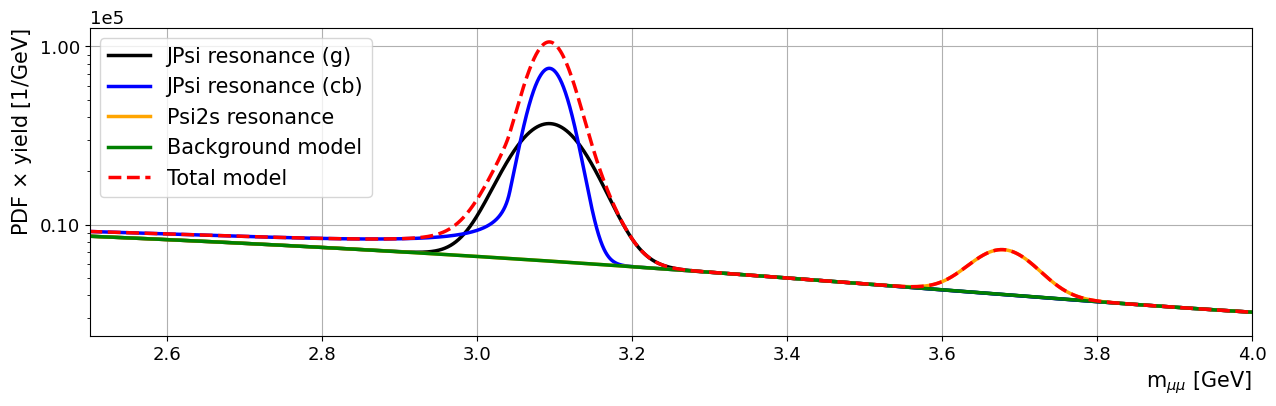

In [8]:
x = np.linspace(2,4.5,10000)
graph_total_model = total_model.pdf(x)*total_model.get_yield()
graph_bkg         = bkg_ext.pdf(x)    *bkg_ext.get_yield()    
graph_cb_JPsi     = cb_jpsi_ext.pdf(x)*cb_jpsi_ext.get_yield() + bkg_ext.pdf(x)*bkg_ext.get_yield()
graph_g_JPsi      = g_jpsi_ext.pdf(x)*g_jpsi_ext.get_yield() + bkg_ext.pdf(x)*bkg_ext.get_yield()
graph_Psi2s       = g_psi2s_ext.pdf(x)*g_psi2s_ext.get_yield()+ bkg_ext.pdf(x)*bkg_ext.get_yield()

#plot the counts divided by bin-size (such that the integral is the total number of events)
_, ax = plt.subplots(1,1, figsize=(15,4))
#ax.errorbar(bin_centers, binned_data/bin_widths, yerr=err_binned_data/bin_widths, fmt='.', label='Data', color = "black")

ax.plot(x,graph_g_JPsi,  label='JPsi resonance (g)', color = "black", linewidth = "2.5")
ax.plot(x,graph_cb_JPsi,  label='JPsi resonance (cb)', color = "blue", linewidth = "2.5")
ax.plot(x,graph_Psi2s, label='Psi2s resonance', color = "orange", linewidth = "2.5")
ax.plot(x,graph_bkg,   label='Background model', color="green", linewidth = "2.5")
ax.plot(x,graph_total_model, label='Total model', color = "red", linewidth = "2.5", linestyle = "--")

ax.set_xlabel("m$_{\\mu\\mu}$ [GeV]", fontsize = fs, loc = "right")
#ax.set_title("Components of the model", fontsize = fs)
ax.set_ylabel(f"PDF $\\times$ yield [1/GeV]", fontsize = fs, loc = "top")
ax.legend(fontsize = fs, loc='upper left')
ax.set_xlim([2.5,4])
ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=tfs)
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((0, 0))
ax.yaxis.offsetText.set_fontsize(tfs)
ax.grid()

plt.savefig("HS_Fit_components_only.png", bbox_inches='tight')
plt.savefig("HS_Fit_components_only.eps", bbox_inches='tight')
plt.show()

Bin number = 133. Minimum number of data inside a bin = 110


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


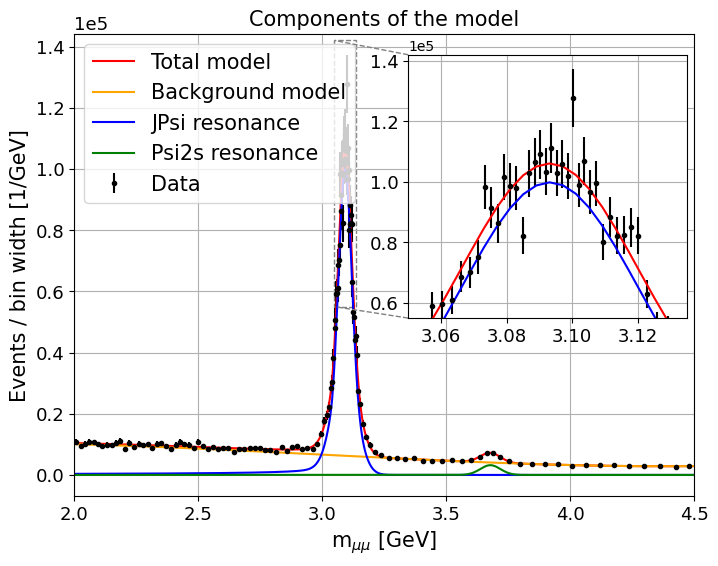

In [9]:
# Creating the plot with each component of the model

points_per_bin  = 180
sorted_data     = np.sort(data_HS)
bin_edges       = [sorted_data[i] for i in range(0, len(data_HS), points_per_bin)]; bin_edges.append(sorted_data[-1])
bin_edges       = np.array(bin_edges)
bin_number      = len(bin_edges)-1
binned_data     = [len(data_HS[(data_HS>bin_edges[i]) & (data_HS<=bin_edges[i+1])]) for i in range(0, bin_number)]
err_binned_data = np.sqrt(binned_data)
bin_centers     = (bin_edges[1:]+bin_edges[:-1])/2
bin_widths      = np.array([bin_edges[i+1]-bin_edges[i] for i in range(0, bin_number)])
print(f"Bin number = {bin_number}. Minimum number of data inside a bin = {np.min(binned_data):.0f}")

x = np.linspace(2,6,1000)
graph_total_model = total_model.pdf(x)*total_model.get_yield()
graph_bkg         = bkg_ext.pdf(x)    *bkg_ext.get_yield()    
graph_JPsi        = cb_jpsi_ext.pdf(x)*cb_jpsi_ext.get_yield()+g_jpsi_ext.pdf(x)*g_jpsi_ext.get_yield()
graph_Psi2s       = g_psi2s_ext.pdf(x)*g_psi2s_ext.get_yield()

#plot the counts divided by bin-size (such that the integral is the total number of events)
_, ax = plt.subplots(1,1, figsize=(8,6))
ax.errorbar(bin_centers, binned_data/bin_widths, yerr=err_binned_data/bin_widths, fmt='.', label='Data', color = "black")
ax.plot(x,graph_total_model, label='Total model', color = "red")
ax.plot(x,graph_bkg,   label='Background model', color="orange")
ax.plot(x,graph_JPsi,  label='JPsi resonance', color = "blue")
ax.plot(x,graph_Psi2s, label='Psi2s resonance', color = "green")

ax_zoom = inset_axes(ax, width="45%", height="57%", loc='upper right', bbox_to_anchor=(0, -0.03, 1, 1), bbox_transform=ax.transAxes)
ax_zoom.errorbar(bin_centers, binned_data/bin_widths, yerr=err_binned_data/bin_widths, fmt='.', label='Data', color = "black")
ax_zoom.plot(x,graph_total_model, label='Total model', color = "red")
ax_zoom.plot(x,graph_bkg,   label='Background model', color="orange")
ax_zoom.plot(x,graph_JPsi,  label='JPsi resonance', color = "blue")
ax_zoom.plot(x,graph_Psi2s, label='Psi2s resonance', color = "green")
x_box = [3.05,3.135]
y_box = [0.55e5,1.42e5]
ax_zoom.set_xlim(x_box)
ax_zoom.set_ylim(y_box)
ax_zoom.yaxis.set_major_formatter(ScalarFormatter())
ax_zoom.yaxis.get_major_formatter().set_scientific(True)
ax_zoom.yaxis.get_major_formatter().set_powerlimits((0, 0))
ax_zoom.grid()
ax_zoom.tick_params(axis='both', labelsize=tfs)
mark_inset(ax, ax_zoom, loc1=2, loc2=3, fc="none", ec="0.5", linestyle='--')

ax.set_xlabel("m$_{\\mu\\mu}$ [GeV]", fontsize = fs)
ax.set_title("Components of the model", fontsize = fs)
ax.set_ylabel(f"Events / bin width [1/GeV]", fontsize = fs)
ax.legend(fontsize = fs, loc='upper left')
ax.tick_params(axis='both', labelsize=tfs)
ax.set_xlim([2,mass_cut_HS])
ax.set_yscale('linear')
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((0, 0))
ax.yaxis.offsetText.set_fontsize(tfs)
ax.grid()

plt.savefig("HS_Fit_components.png", bbox_inches='tight')
plt.savefig("HS_Fit_components.eps", bbox_inches='tight')
plt.show()

C:\Users\Gabriele\AppData\Local\Temp\ipykernel_3124\3485538762.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


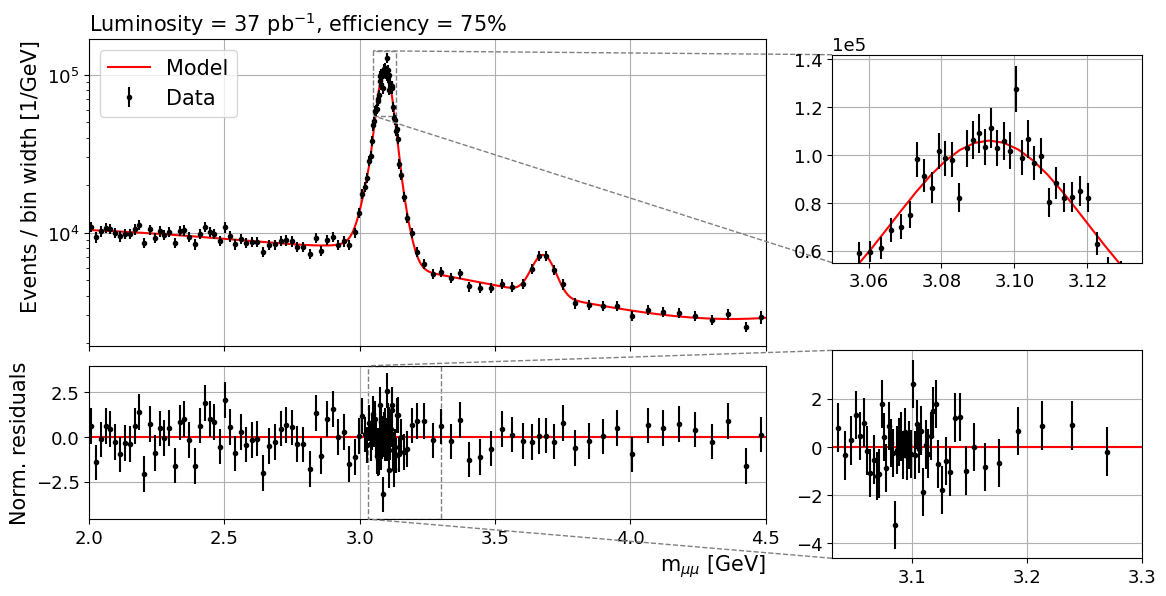

In [10]:
# Plotting only the combined model over the data in log scale and the residuals
fig, (ax_plot, ax_res) = plt.subplots(2,1, figsize=(8,6), sharex = True, gridspec_kw={'height_ratios': [2, 1]})
x = np.linspace(2,6,1000)
graph_total_model = total_model.pdf(x)*total_model.get_yield()

#plot the counts divided by bin-size (such that the integral is the total number of events)
#ax_plot.set_title("Fit results", fontsize = fs)
ax_plot.plot(x, graph_total_model, label='Model', color = "red")
ax_plot.errorbar(bin_centers, binned_data/bin_widths, yerr=err_binned_data/bin_widths , fmt='.', color = 'black', label='Data')

ax_zoom = inset_axes(ax_plot, width="50%", height="45%", loc='upper right', bbox_to_anchor=(0.7, 0.04, 1, 1), bbox_transform=ax.transAxes)
ax_zoom.plot(x, graph_total_model, label='Model', color = "red")
ax_zoom.errorbar(bin_centers, binned_data/bin_widths, yerr=err_binned_data/bin_widths , fmt='.', color = 'black', label='Data')
x_box = [3.05,3.135]
y_box = [0.55e5,1.42e5]
ax_zoom.set_xlim(x_box)
ax_zoom.set_ylim(y_box)
ax_zoom.yaxis.set_major_formatter(ScalarFormatter())
ax_zoom.yaxis.get_major_formatter().set_scientific(True)
ax_zoom.yaxis.get_major_formatter().set_powerlimits((0, 0))
ax_zoom.yaxis.offsetText.set_fontsize(tfs)
ax_zoom.grid()
ax_zoom.tick_params(axis='both', labelsize=tfs)
mark_inset(ax_plot, ax_zoom, loc1=2, loc2=3, fc="none", ec="0.5", linestyle='--')

ax_plot.set_xlim([2,6])
ax_plot.set_ylabel(f"Events / bin width [1/GeV]", fontsize = fs, loc = "top")
ax_plot.legend(fontsize = fs, loc='upper left')
ax_plot.grid()
ax_plot.set_yscale('log')
ax_plot.tick_params(axis='both', labelsize=tfs)
ax_plot.set_title("Luminosity = 37 pb$^{-1}$, efficiency = 75%", loc = "left", fontsize = fs)

#plot the residuals
residuals = (binned_data/bin_widths - total_model.pdf(bin_centers)*total_model.get_yield()) 
ax_res.axhline(0, color = "red")
ax_res.errorbar(bin_centers, residuals/(err_binned_data/bin_widths),yerr=1, fmt='.', color = 'black')

ax_zoom = inset_axes(ax_res, width="50%", height="45%", loc='upper right', bbox_to_anchor=(0.7, -0.6, 1, 1), bbox_transform=ax.transAxes)
ax_zoom.axhline(0, color = "red")
ax_zoom.errorbar(bin_centers, residuals/(err_binned_data/bin_widths),yerr=1, fmt='.', color = 'black')
x_box = [3.03,3.3]
#y_box = [-4,4]
#y_box = [-2.7e4,3.6e4]
ax_zoom.set_xlim(x_box)
#ax_zoom.set_ylim(y_box)
ax_zoom.yaxis.set_major_formatter(ScalarFormatter())
ax_zoom.yaxis.get_major_formatter().set_scientific(True)
ax_zoom.yaxis.get_major_formatter().set_powerlimits((0, 0))
ax_zoom.yaxis.offsetText.set_fontsize(tfs)
ax_zoom.tick_params(axis='both', labelsize=tfs)
ax_zoom.grid()
mark_inset(ax_res, ax_zoom, loc1=2, loc2=3, fc="none", ec="0.5", linestyle='--')

ax_res.set_xlim([2,mass_cut_HS])
ax_res.set_ylabel("Norm. residuals", fontsize = fs)
ax_res.set_xlabel("m$_{\\mu\\mu}$ [GeV]", fontsize = fs, loc = "right")
ax_res.tick_params(axis='both', labelsize=tfs)
ax_res.yaxis.set_major_formatter(ScalarFormatter())
ax_res.yaxis.get_major_formatter().set_scientific(True)
ax_res.yaxis.get_major_formatter().set_powerlimits((0, 0))
ax_res.yaxis.offsetText.set_fontsize(tfs)
ax_res.grid()


plt.tight_layout()
plt.savefig("HS_Fit.png", bbox_inches='tight')
plt.savefig("HS_Fit.eps", bbox_inches='tight')
plt.show()

### Analysis of the residuals

chi2/ndf = 0.99, max chi2/ndf = 1.22 for a significance level of 95%, ndf = 119
Given a total number of residuals equal to 133, we have found
 - 72.9% residuals in 1 sigma
 - 96.2% residuals in 2 sigma


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


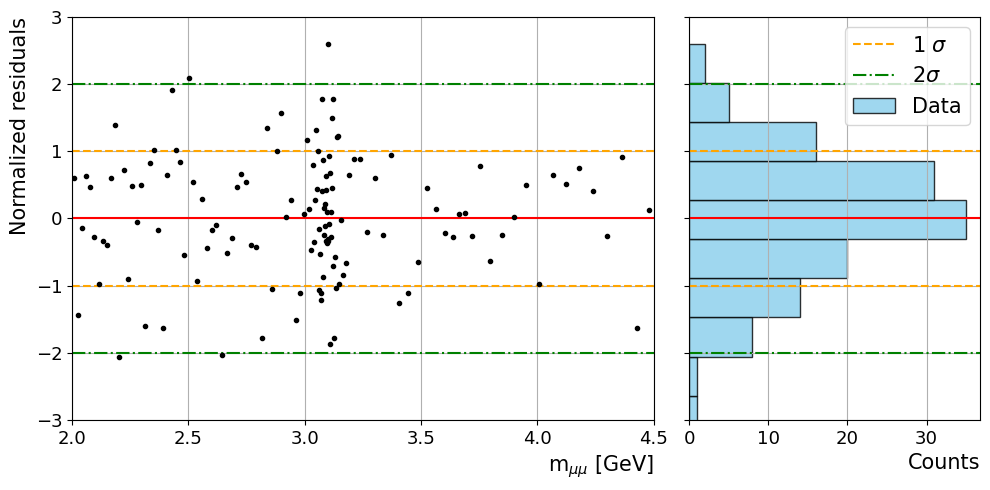

In [11]:
#Plot of the residuals
fig, (ax_plot, ax_hist) = plt.subplots(1,2, figsize=(10,5), sharey = True, gridspec_kw={'width_ratios': [2, 1]})

#compute normalized residuals
norm_residuals = (binned_data/bin_widths - total_model.pdf(bin_centers)*total_model.get_yield()) / (err_binned_data/bin_widths)
frac_1sigma = len(norm_residuals[np.abs(norm_residuals) <1]) / len(norm_residuals)
frac_2sigma = len(norm_residuals[np.abs(norm_residuals) <2]) / len(norm_residuals)

#Compute chi squared
ndf = len(norm_residuals) - len(result.values) # I have a doubt here: the 12 parameters we extracted were estimated starting from UNBINNED data, so the original number of degrees of freedom is len(data_HS)?
chi2_norm = np.sum(norm_residuals**2) / ndf
significance_level = 0.95
chi2_limit = chi2.ppf(significance_level, ndf) / ndf

print(f"chi2/ndf = {chi2_norm:.2f}, max chi2/ndf = {chi2_limit:.2f} for a significance level of {significance_level*100:.0f}%, ndf = {ndf}")
print(f"Given a total number of residuals equal to {len(norm_residuals)}, we have found")
print(f" - {frac_1sigma*100:.1f}% residuals in 1 sigma")
print(f" - {frac_2sigma*100:.1f}% residuals in 2 sigma")

#First subplot of normalized residuals
ax_plot.axhline(0, color = "red")
ax_plot.axhline(1, color = "orange", linestyle="--", label = "1$\\sigma$")
ax_plot.axhline(-1, color = "orange", linestyle="--")
ax_plot.axhline(2, color = "green", linestyle="-.", label = "2$\\sigma$")
ax_plot.axhline(-2, color = "green", linestyle="-.")
ax_plot.errorbar(bin_centers, norm_residuals, fmt='.', color = 'black', label='Data')

ax_plot.set_xlim([2,mass_cut_HS])
ax_plot.set_ylim([-3,3])
ax_plot.set_ylabel("Normalized residuals",fontsize = fs, loc = "top")
ax_plot.set_xlabel("m$_{\\mu\\mu}$ [GeV]", fontsize = fs, loc = "right")
ax_plot.grid()
ax_plot.tick_params(axis='both', labelsize=tfs)

#ax_plot.text(2.0,3.2, f'Residuals in 1$\\sigma$: {frac_1sigma * 100:.1f}%\nResiduals in 2$\\sigma$: {frac_2sigma * 100:.1f}%\n$\chi^2$/ndf = {chi2_norm:.2f} (max {chi2_limit:.2f} at 95% SL)', color='black', fontsize = fs)

#histogram of the normalized residuals
ax_hist.axhline(0, color = "red")
ax_hist.axhline(1, color = "orange", linestyle="--", label = "1 $\\sigma$")
ax_hist.axhline(-1, color = "orange", linestyle="--")
ax_hist.axhline(2, color = "green", linestyle="-.", label = "2$\\sigma$")
ax_hist.axhline(-2, color = "green", linestyle="-.")

ax_hist.hist(norm_residuals, bins=10, orientation='horizontal', color='skyblue', alpha = 0.8, edgecolor='black', label='Data')
ax_hist.set_xlabel("Counts", fontsize = fs, loc = "right")
ax_hist.grid()
ax_hist.legend(fontsize = fs, loc='upper right')
ax_hist.tick_params(axis='both', labelsize=tfs)


plt.tight_layout()

plt.savefig("HS_Residuals.png", bbox_inches='tight')
plt.savefig("HS_Residuals.eps", bbox_inches='tight')
plt.show()

## Run test
Given N_+ data above the model and N_- below, the distribution of the number of runs, under the null hypothesis $H_0$ that the data are randomly distributed around the model, follows the following probability function:
\begin{equation}
    P(R) = \begin{cases}
        \displaystyle 2 \frac{comb(N_+-1, s-1) * comb(N_- -1,s-1)}{comb(N_++N_-, N_+)} \text{ if } R = 2s\\
        \displaystyle \frac{comb(N_+-1, s-1) * comb(N_- -1,s-2) + comb(N_+-1, s-2) * comb(N_- -1,s-1)}{comb(N_++N_-, N_+)} \text{ if } R = 2s-1\\
    \end{cases}
\end{equation}

If $N_+ \neq N_-$ both different from 0 (our case), the minimum number of runs is $r = 2$ (++++++------), while the maximum number is $r = 2*min(N_+,N_-)+1$. In fact, suppose we have less positive data, we can make a fully alternate sequence (-+-+-+-+) until all + run out, getting $2*N_+$ runs; 
then we have to use all the remaining minus signs, adding one run (-+-+-+-+)(--------). If I added one of the final minuses near another minus in the alternate sequence, we would not change the run number (remains the maximum possible). Moving the entire (-----) sequence inside the alternate sequence, The number of runs would decrease by 1 ex. (-+-+-+---------+). So we can only decrease the number of runs.

The goal of this section is to test the hypothesys that the data are randomly distributed around the model. This is done by computing the number of observed runs and $P(R|H_0)$. The compatibility of the observed number of runs with the hypothetical parent distribution is tested defining a rejection region for a significance level of $90\%$.

In [12]:
# Counting how many adiacent residuals have the same sign

runs = [] # Will contain the runs, the number of residuals having the same sign
j    = 1  # It will count the number of residuals of same sign in the current chunk (already starting from the first residual)
for i in range(1, len(norm_residuals)):
    if norm_residuals[i]*norm_residuals[i-1] > 0: # This happens when they have the same sign
        j+=1
    else:
        runs.append(j)
        j = 1
runs.append(j) # To include the final run

In [13]:
# Counting the positive and negative residuals

N_pos = len(norm_residuals[norm_residuals>0])
N_neg = len(norm_residuals[norm_residuals<0])

print(f"Number of positive residuals: {N_pos}")
print(f"Number of negative residuals: {N_neg}")

# Evaluating the expected average number of runs and its variance
# Formulae taken from James, "Statistical methods in Experimental Physics" pg 309

mean_runs_number = 1 + 2*N_pos*N_neg/(N_pos+N_neg)
var_runs_number  = 2*N_pos*N_neg*(2*N_pos*N_neg-N_pos-N_neg)/(N_pos+N_neg)**2/(N_pos+N_neg-1)

# Comparing our value with the expected one

print(f"Measured number of runs: {len(runs)}")
print(f"Expected number of runs: {mean_runs_number:.1f} with std = {np.sqrt(var_runs_number):.1f}")

Number of positive residuals: 68
Number of negative residuals: 65
Measured number of runs: 73
Expected number of runs: 67.5 with std = 5.7


In [14]:
#probability function of runs
R = range(2, 2*min(N_pos, N_neg) + 1)

runs_pdf = []
for r in R:
    if r%2 == 0: # This happens if r is even
        s = int(r/2)
        runs_pdf.append( 2*math.comb(N_pos-1, s-1)*math.comb(N_neg-1,s-1)/math.comb(N_pos+N_neg,N_pos) )
    else:
        s = int((r+1)/2)
        runs_pdf.append( (math.comb(N_pos-1, s-2)*math.comb(N_neg-1,s-1) + math.comb(N_pos-1, s-1)*math.comb(N_neg-1,s-2))/math.comb(N_pos+N_neg,N_pos) )

print(f"Normalization: {sum(runs_pdf)}")

Normalization: 1.0


In [15]:
#Defining the rejection interval
CDF = np.cumsum(runs_pdf)
alpha = 0.05
significance_level = 1-alpha
quantile = R[np.searchsorted(CDF, alpha, side = 'left')]
print(f"Integrating up to R = {R[np.searchsorted(CDF, alpha, side = 'left')]}: cumulative = {CDF[np.searchsorted(CDF, alpha)]:.3f}")
print(f"Given a significance level of {significance_level}, the critical region is R < R_min = {quantile}")

Integrating up to R = 58: cumulative = 0.059
Given a significance level of 0.95, the critical region is R < R_min = 58


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


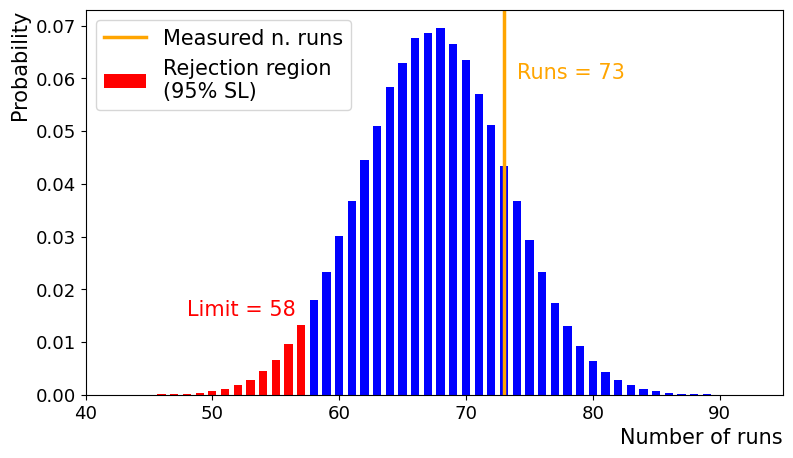

In [16]:
# Plotting the probability distribution of the runs number and Hypothesis Testing
plt.figure(figsize = (9,5))
plt.bar(R[np.searchsorted(CDF, alpha, side = 'left'):], runs_pdf[np.searchsorted(CDF, alpha, side = 'left'):], width = 0.65, color = 'b')
plt.bar(R[0:np.searchsorted(CDF, alpha, side = 'left')], runs_pdf[0:np.searchsorted(CDF, alpha, side = 'left')], width = 0.65, color = 'r', label = "Rejection region\n(95% SL)")
plt.axvline(len(runs), color='orange',linewidth = "2.5", label = "Measured n. runs")

plt.xlim([40,95])
plt.legend(fontsize = fs)
#plt.title("Run test", fontsize = fs)
plt.ylabel("Probability", fontsize = fs, loc = "top")
plt.xlabel("Number of runs", fontsize = fs, loc = "right")
plt.text(len(runs)+1, 0.06, f"Runs = {len(runs)}", fontsize = fs, color = "orange")
plt.text(R[np.searchsorted(CDF, alpha, side = 'left')] - 10, 0.015, f"Limit = {R[np.searchsorted(CDF, alpha, side = 'left')]}", fontsize = fs, color = "red")
plt.tick_params(axis='both', labelsize=tfs)

plt.savefig("HS_Runs_distribution.png", bbox_inches='tight')
plt.savefig("HS_Runs_distribution.eps", bbox_inches='tight')
plt.show()


## Kolmogorov-Smirnov

In [53]:
# Wrap zfit PDF in a scalar-evaluable function
def total_pdf_scalar(x):
    if 2.0 <= x <= mass_cut_HS:
        x_tensor = zfit.Data.from_numpy(obs=obs, array=np.array([x]))
        return total_model.pdf(x_tensor).numpy()[0]  # extract scalar result
    else:
        return 0.0

def total_cdf_scalar(x):
    if x < 2.0:
        return 0.0
    elif x > mass_cut_HS:
        return 1.0
    else:
        return quad(total_pdf_scalar, 2, x)[0]

#vectorize the function to give arrays as inputs
total_cdf = np.vectorize(total_cdf_scalar)

In [52]:
ks_stat, p_value = ks_1samp(data_HS, cdf=total_cdf)

print("One-Sample K-S Test:")
print(f"KS Statistic: {ks_stat:.4f}")
print(f"P-value: {p_value:.4f}")

KeyboardInterrupt: 

In [ ]:
# Empirical CDF
data_HS_sorted = np.sort(data_HS)
empirical_cdf = np.arange(1, len(data_HS_sorted) + 1) / len(data_HS_sorted)

# Theoretical CDF
x = np.linspace(2, 6, 1000)
theoretical_cdf = total_cdf(x)

# Plot CDFs
plt.figure(figsize=(10, 5))
plt.plot(data_HS_sorted, empirical_cdf, label='Empirical CDF', color='blue')
plt.plot(x, theoretical_cdf, label='Total model CDF', color='red', linestyle='--')
plt.xlabel('mass')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# (1) Defining the bkg only hypothesis
#bkg_only_hypothesis = POI(xs_psi2s, 0)

#(2)
#calculator_HS = AsymptoticCalculator(input=loss, minimizer=minimizer)

# (3) Discovery significance computation (get pvalue and sigmas)
#discovery = Discovery(calculator=calculator_HS, poinull=bkg_only_hypothesis)
#discovery.result()

In [18]:
# Range of xs_psi2s values to scan. (perform discovery test before this)
#xs_psi2s_scan = POIarray(xs_psi2s, np.linspace(0, 40, 40))
#ul = UpperLimit(calculator=calculator_HS, poinull=xs_psi2s_scan, poialt=bkg_only_hypothesis)

In [19]:
#plotlimit(ul, CLs=False)
#plt.legend(fontsize = fs, loc='upper left', bbox_to_anchor=(1, 1))

#plt.savefig("HS_upper_limit.png")
#plt.show()

In [20]:
#ul.upperlimit(alpha=0.05)

# 4. Displaying the profile Likelihood

## 4.1. No systematic uncertainty

In [68]:
NLL_size = 10
xs_values = np.linspace(9,15,NLL_size)
NLL_values = np.zeros(NLL_size)

for i,xs in enumerate(xs_values):
    yield_psi2s = eps_uu * lumi * xs
    g_psi2s_ext = g_psi2s.create_extended(yield_psi2s)
    total_model = zfit.pdf.SumPDF([total_jpsi_ext, g_psi2s_ext, bkg_ext])

    loss = zfit.loss.ExtendedUnbinnedNLL(model = total_model,
                                         data = data)
    minimizer = zfit.minimize.Minuit()
    temp_result = minimizer.minimize(loss)
    NLL_values[i] = temp_result.fmin

#winsound.Beep(1000, 3000)

In [69]:
min_NLL = result.fmin
NLL_variation = 2*(NLL_values-min_NLL)
xs_temporary = xs_values[NLL_variation<1]
xs_interval = [np.min(xs_temporary), np.max(xs_temporary)]
print(f"The confidence interval [{xs_interval[0]:.3f},{xs_interval[1]:.3f}] contains the true value of the parameter at a confidence level of 68%")

The confidence interval [10.333,13.000] contains the true value of the parameter at a confidence level of 68%


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


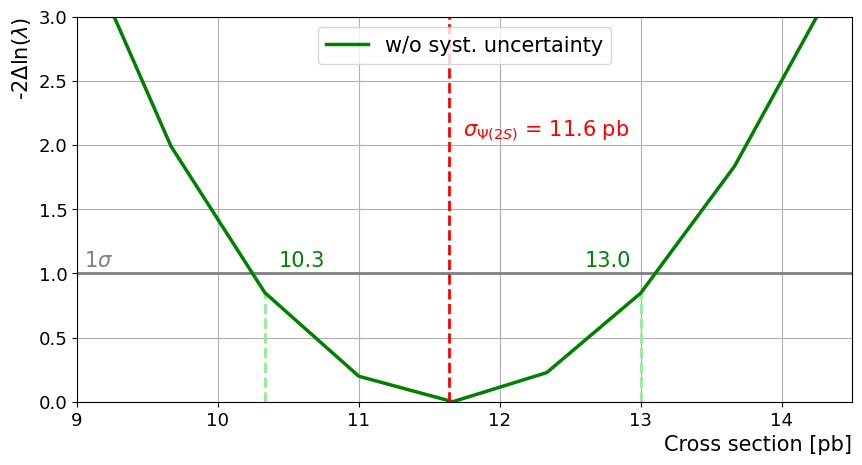

In [70]:
# Displaying the results
plt.figure(figsize=(10,5))
plt.plot(xs_values, np.ones(NLL_size), color='grey', linewidth=2)
plt.text(9.05,1.05, "$1\sigma$", color='gray', fontsize = fs) #this line does not work for some reason

plt.plot([xs_interval[0], xs_interval[0]], [0, NLL_variation[NLL_variation<1][0]], color='lightgreen', linestyle = "--", linewidth=2)
plt.plot([xs_interval[1], xs_interval[1]], [0, NLL_variation[NLL_variation<1][-1]],color='lightgreen', linestyle = "--", linewidth=2)

plt.plot(xs_values, NLL_variation, color = 'green', label='w/o syst. uncertainty', linewidth=2.5)
plt.axvline(result_xs_psi2s, color='red', linestyle = "--", linewidth=2)
#plt.title('Confidence interval (likelihood ratio method)', fontsize = fs)
plt.xlabel('Cross section [pb]', fontsize = fs, loc = "right")
plt.ylabel('-2$\\Delta$ln($\lambda$)', fontsize = fs, loc = "top")
plt.grid()
plt.tick_params(axis='both', labelsize=tfs)
plt.ylim([0.,3.])
plt.xlim([9.,14.5])
plt.text(xs_interval[0]+0.1,1.05, f'{xs_interval[0]:.1f}', color='green', fontsize = fs)
plt.text(xs_interval[1]-0.4,1.05, f'{xs_interval[1]:.1f}', color='green', fontsize = fs)
plt.text(result_xs_psi2s+0.1,2.07, "$\sigma_{\Psi(2S)}$"+f" = {result.values[2]:.1f} pb", color='red', fontsize = fs)
plt.legend(fontsize = fs, loc='upper center')

plt.savefig("no_sys_LR.png")
plt.savefig("no_sys_LR.eps")
plt.show()

## 4.2. Systematic uncertainty on the efficiency

In [71]:
# Defining the nominal k parameter and the uncertainty 
nominal_k = 1.0
eff_uncertainty = 0.1

#parameter where we apply the gaussian constraint
k = zfit.Parameter("k", 1, 0.5, 1.5)

#composite parameter that contains two degrees of freedom: k and xs
yield_psi2s = zfit.ComposedParameter("yield_psi2s", lambda xs, k: k * eps_uu * lumi * xs, params=[xs_psi2s, k])

#introduce the gaussian constraint
k_constraint = zfit.constraint.GaussianConstraint(params=k, observation=nominal_k, uncertainty=eff_uncertainty)

g_psi2s = zfit.pdf.Gauss(obs=obs, mu=mu_psi2s, sigma=sigma_psi2s)
g_psi2s_ext = g_psi2s.create_extended(yield_psi2s)

#Total model
total_model = zfit.pdf.SumPDF([total_jpsi_ext, g_psi2s_ext, bkg_ext])

loss = zfit.loss.ExtendedUnbinnedNLL(   model = total_model,
                                        data = data,
                                        constraints = [k_constraint])
minimizer = zfit.minimize.Minuit()
result_sys = minimizer.minimize(loss)
result_sys.hesse()
print(result_sys)

FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_159, Composed_autoparam_160, Composed_autoparam_161]] data=[<zfit.Data: Data obs=('mass',) shape=(23871, 1)>] constraints=[<zfit.core.constraint.GaussianConstraint object at 0x0000026BD0BDCD00>]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 1.1e-05 │          9529.70 |  10007.36 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name             value  (rounded)        hesse    at limit
-------------  ------------------  -----------  ----------
yield_cb_jpsi             5159.36  +/- 5.1e+02       False
yield_g_jpsi               3673.6  +/- 5

In [72]:
# Evaluating the minimum NLL while the cross section is fixed (Profile Likelihood)

NLL_values_sys = np.zeros(NLL_size)

for i, xs in enumerate(xs_values):
    yield_psi2s = zfit.ComposedParameter("yield_psi2s", lambda  k: k * eps_uu * lumi * xs, params=[k])
    g_psi2s_ext = g_psi2s.create_extended(yield_psi2s)
    total_model = zfit.pdf.SumPDF([total_jpsi_ext, g_psi2s_ext, bkg_ext])

    loss = zfit.loss.ExtendedUnbinnedNLL(   model = total_model,
                                            data = data,
                                            constraints = [k_constraint])
    minimizer = zfit.minimize.Minuit()
    temp_result = minimizer.minimize(loss)
    NLL_values_sys[i] = temp_result.fmin

#winsound.Beep(1000, 3000)

In [73]:
min_NLL_sys = result_sys.fmin
NLL_variation_sys = 2*(NLL_values_sys-min_NLL_sys)
xs_temporary_sys = xs_values[NLL_variation_sys<1]
xs_interval_sys = [np.min(xs_temporary_sys), np.max(xs_temporary_sys)]
print(f"The confidence interval [{xs_interval_sys[0]:.3f},{xs_interval_sys[1]:.3f}] contains the true value of the parameter at a confidence level of 68%")

The confidence interval [10.333,13.000] contains the true value of the parameter at a confidence level of 68%


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


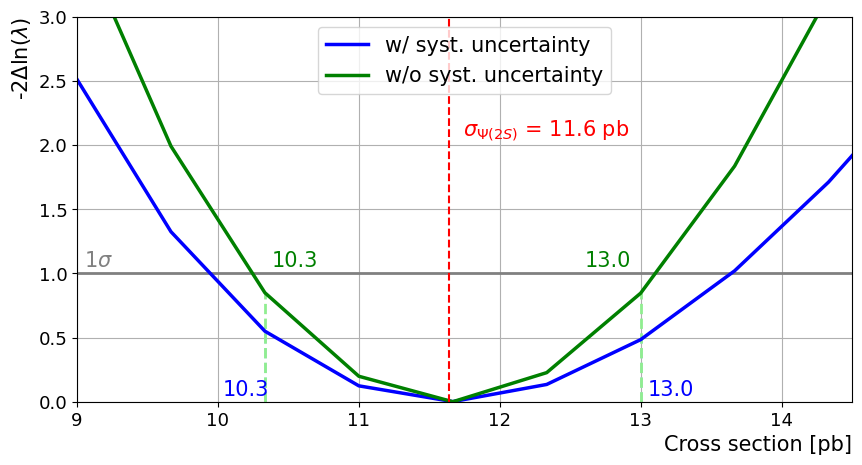

In [74]:
# Displaying the results
plt.figure(figsize=(10,5))
plt.plot(xs_values, np.ones(NLL_size), color='grey', linewidth=2)
plt.text(9.05,1.05, "$1\sigma$", color='gray', fontsize = fs) #this line does not work for some reason

plt.plot([xs_interval_sys[0], xs_interval_sys[0]], [0, NLL_variation_sys[NLL_variation_sys<1][0]], color='lightblue', linestyle = "--", linewidth=2)
plt.plot([xs_interval_sys[1], xs_interval_sys[1]], [0, NLL_variation_sys[NLL_variation_sys<1][-1]],color='lightblue', linestyle = "--", linewidth=2)
plt.plot([xs_interval[0], xs_interval[0]], [0, NLL_variation[NLL_variation<1][0]], color='lightgreen', linestyle = "--", linewidth=2)
plt.plot([xs_interval[1], xs_interval[1]], [0, NLL_variation[NLL_variation<1][-1]],color='lightgreen', linestyle = "--", linewidth=2)

plt.plot(xs_values, NLL_variation_sys, color = "blue", label='w/ syst. uncertainty', linewidth=2.5)
plt.plot(xs_values, NLL_variation, color = 'green', label='w/o syst. uncertainty', linewidth=2.5)
plt.axvline(result_sys.values[2], color='red', linestyle = "--")
#plt.title('Confidence interval (likelihood ratio method)', fontsize = fs)
plt.xlabel('Cross section [pb]', fontsize = fs, loc = "right")
plt.ylabel('-2$\\Delta$ln($\lambda$)', fontsize = fs, loc = "top")
plt.grid()
plt.tick_params(axis='both', labelsize=tfs)
plt.ylim([0.,3.])
plt.xlim([9.,14.5])
plt.text(xs_interval_sys[0]-0.3,0.05, f'{xs_interval_sys[0]:.1f}', color='blue', fontsize = fs)
plt.text(xs_interval_sys[1]+0.05,0.05, f'{xs_interval_sys[1]:.1f}', color='blue', fontsize = fs)
plt.text(xs_interval[0]+0.05,1.05, f'{xs_interval[0]:.1f}', color='green', fontsize = fs)
plt.text(xs_interval[1]-0.4,1.05, f'{xs_interval[1]:.1f}', color='green', fontsize = fs)
plt.text(result_sys.values[2]+0.1,2.07, "$\sigma_{\Psi(2S)}$"+f" = {result_sys.values[2]:.1f} pb", color='red', fontsize = fs)
plt.legend(fontsize = fs, loc='upper center')

plt.savefig("sys_LR.png")
plt.savefig("sys_LR.eps")
plt.show()

In [75]:
print(f"xs = {result_sys.values[2]} + {result_sys.values[2]-xs_interval_sys[0]} - {-result_sys.values[2]+xs_interval_sys[1]}")

xs = 11.636842414564937 + 1.3035090812316028 - 1.3631575854350633


# 5. Low statistic analysis

Notes:
The "significance" (or "excess significance") is the probability that the bump observed is due to the fluctuation of the null hypothesis, measurable through p-value.
If the p-value is smaller, then the result is said to be more significant.

(1) What the POI class does is to take as input a zfit.Parameter instance and a value corresponding to a given hypothesis. You can notice that we didn’t define here the alternative hypothesis as in the discovery test the value of POI for alternate is set to the best fit value.

(2) The construction of the test statistic and the computation of the p-value is done in a Calculator object in hepstats. We use the profile likelihood ratio as test statistic: in the asymptotic limit this follows a chi squared pdf wit ndf = 1. This means that $p_0^{obs} = 1-\Phi(\sqrt{q_0^{obs}})$.

(3) The Discovery class is a high-level class that takes as input a calculator and a POI instance representing the null hypothesis, it basically asks the calculator to compute the p-value and also computes the signifance as $Z = \sqrt{q_0}$.

The upper limit on $\sigma_{\Psi_{2s}}$ (call it $\sigma_{\Psi_{2s}}+$) is found for $p_{\sigma_{\Psi_{2s}}+}$ = $1- \alpha$, $\alpha$ being the confidence level (typically 95%). The upper limit is found by interpolation of the p-values as a function of $\sigma_{\Psi_{2s}}$ which is done the UpperLimit class. We have to give the range of values of $\sigma_{\Psi_{2s}}$to scan using the POIarray class which as the POI class takes as input the parameter but takes several values to evaluate the parameter instead of one.

# Low statistics fit
## Performing the fit

In [8]:
#Parameters, observables and fit (all redefined in case we want to modify some parameters)
obs = zfit.Space('mass', limits=(2.0, mass_cut_LS))  # GeV
eps_uu = 0.75
lumi = 0.64 #changed (much lower)

# Background parameters
a1 = zfit.Parameter("a1", -0.7, -2, 2)
a2 = zfit.Parameter("a2", 0.3, -2, 2)
a3 = zfit.Parameter("a3", -0.03, -2, 2)
yield_bkg = zfit.Parameter("yield_bkg", 300, 0, 500) #changed yield and limit (less data)

bkg = zfit.pdf.Chebyshev(obs=obs, coeffs=[a1, a2, a3])
bkg_ext = bkg.create_extended(yield_bkg)

# J/ψ Crystal Ball parameters
mu_jpsi = zfit.Parameter("mu_jpsi", 3.1, 2.8, 3.2)
sigma_jpsi = zfit.Parameter("sigma_jpsi", 0.03, 0.01, 0.1)
alpha_jpsi = zfit.Parameter("alpha_jpsi", 1.5, -5, 5)
n_jpsi = zfit.Parameter("n_jpsi", 1.5, 0.5, 10)

sigma_cb_jpsi = zfit.Parameter("sigma_cb_jpsi", 0.03, 0.01, 0.1)
sigma_g_jpsi = zfit.Parameter("sigma_g_jpsi", 0.03, 0.01, 0.1)

yield_g_jpsi = zfit.Parameter("yield_g_jpsi", 160, 0.0, 500)
yield_cb_jpsi = zfit.ComposedParameter("yield_cb_jpsi", lambda yield_g: yield_g * jpsi_yield_ratio, params=[yield_g_jpsi])

cb_jpsi     = zfit.pdf.CrystalBall(obs=obs, mu=mu_jpsi, sigma=sigma_cb_jpsi, alpha=alpha_jpsi, n=n_jpsi) 
cb_jpsi_ext = cb_jpsi.create_extended(yield_cb_jpsi)
g_jpsi     = zfit.pdf.Gauss(obs=obs, mu=mu_jpsi, sigma=sigma_g_jpsi)
g_jpsi_ext = g_jpsi.create_extended(yield_g_jpsi)
cb_jpsi = zfit.pdf.CrystalBall(obs=obs, mu=mu_jpsi, sigma=sigma_cb_jpsi, alpha=alpha_jpsi, n=n_jpsi)
cb_jpsi_ext = cb_jpsi.create_extended(yield_cb_jpsi) 
total_jpsi_ext = zfit.pdf.SumPDF([cb_jpsi_ext, g_jpsi_ext])

# Psi(2S) gaussian parameters
xs_psi2s = zfit.Parameter("xs_psi2s", 9., 0.0, 40.0)
yield_psi2s = zfit.ComposedParameter("yield_psi2s", lambda xs:eps_uu * lumi * xs, params=[xs_psi2s])

g_psi2s = zfit.pdf.Gauss(obs=obs, mu=result_mu_psi2s, sigma=result_sigma_psi2s) #fixed these parameters of psi2s: params taken from first HS fit
g_psi2s_ext = g_psi2s.create_extended(yield_psi2s) #yield not fixed (it must be free to set upper limit, right? It does not make sense otherwise)

#Total model
total_model = zfit.pdf.SumPDF([total_jpsi_ext, g_psi2s_ext, bkg_ext])

data = zfit.Data.from_numpy(obs   = obs,
                            array = data_LS)

loss = zfit.loss.ExtendedUnbinnedNLL(   model = total_model,
                                        data = data)
minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(loss)
result.hesse()
print(result)

FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_17, Composed_autoparam_18, Composed_autoparam_19]] data=[<zfit.Data: Data obs=('mass',) shape=(420, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 9.8e-05 │           163.80 |  9928.728 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name             value  (rounded)        hesse    at limit
-------------  ------------------  -----------  ----------
yield_g_jpsi              60.7562  +/-     7.2       False
xs_psi2s                  7.66673  +/-     8.7       False
yield_bkg                  270.41  +/-      21       Fal

## Plots

Min number of events in a bin: 1


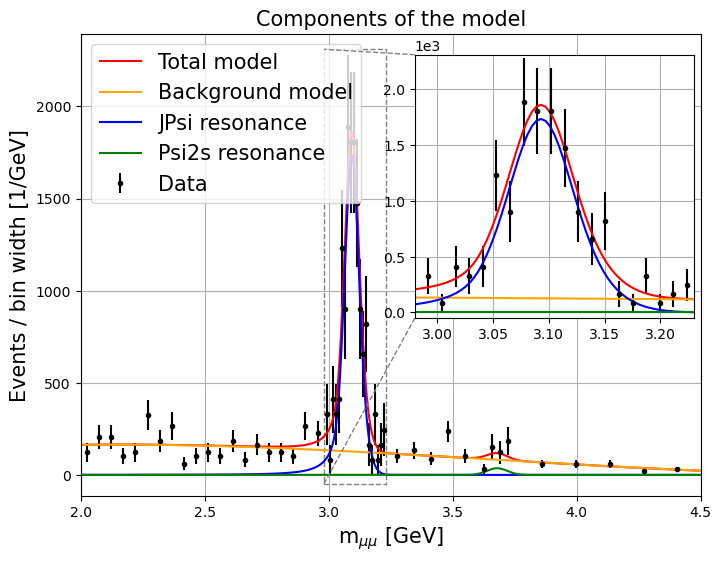

In [9]:
# Creating the plot with each component of the model
#in this context the bins and errors given to them is just a way to compare directly the model and the data, but
#there is not any quantitative purpose since many bins have 0 data and if we decrease the number of bins we don't populate the peaks enough.

cuts = [2.98, 3.23, 3.61, 3.78]
data_bkg_A = data_LS[data_LS<cuts[0]];                       #print(f'bkg_A length: {len(data_bkg_A)}')
data_JPsi  = data_LS[(data_LS>cuts[0]) & (data_LS<cuts[1])]; #print(f'JPsi  length: {len(data_JPsi )}')
data_bkg_B = data_LS[(data_LS>cuts[1]) & (data_LS<cuts[2])]; #print(f'bkg_B length: {len(data_bkg_B)}')
data_Psi2s = data_LS[(data_LS>cuts[2]) & (data_LS<cuts[3])]; #print(f'Psi2s length: {len(data_Psi2s)}')
data_bkg_C = data_LS[data_LS>cuts[3]];                       #print(f'bkg_C length: {len(data_bkg_C)}')

bin_numbers = [20,20,5,4,5]
binned_bkg_A, bin_edges_bkg_A = np.histogram(data_bkg_A,bin_numbers[0])
binned_JPsi , bin_edges_JPsi  = np.histogram(data_JPsi ,bin_numbers[1])
binned_bkg_B, bin_edges_bkg_B = np.histogram(data_bkg_B,bin_numbers[2])
binned_Psi2s, bin_edges_Psi2s = np.histogram(data_Psi2s,bin_numbers[3])
binned_bkg_C, bin_edges_bkg_C = np.histogram(data_bkg_C,bin_numbers[4])

print(f"Min number of events in a bin: {np.min(np.concatenate((binned_bkg_A, binned_JPsi, binned_bkg_B, binned_Psi2s, binned_bkg_C)))}")

err_binned_bkg_A = np.sqrt(binned_bkg_A)
err_binned_JPsi  = np.sqrt(binned_JPsi )
err_binned_bkg_B = np.sqrt(binned_bkg_B)
err_binned_Psi2s = np.sqrt(binned_Psi2s)
err_binned_bkg_C = np.sqrt(binned_bkg_C)

bin_centers_bkg_A = (bin_edges_bkg_A[1:]+bin_edges_bkg_A[:-1])/2
bin_centers_JPsi  = (bin_edges_JPsi [1:]+bin_edges_JPsi [:-1])/2
bin_centers_bkg_B = (bin_edges_bkg_B[1:]+bin_edges_bkg_B[:-1])/2
bin_centers_Psi2s = (bin_edges_Psi2s[1:]+bin_edges_Psi2s[:-1])/2
bin_centers_bkg_C = (bin_edges_bkg_C[1:]+bin_edges_bkg_C[:-1])/2

bin_width_bkg_A = bin_edges_bkg_A[1]-bin_edges_bkg_A[0]
bin_width_JPsi  = bin_edges_JPsi [1]-bin_edges_JPsi [0]
bin_width_bkg_B = bin_edges_bkg_B[1]-bin_edges_bkg_B[0]
bin_width_Psi2s = bin_edges_Psi2s[1]-bin_edges_Psi2s[0]
bin_width_bkg_C = bin_edges_bkg_C[1]-bin_edges_bkg_C[0]


bin_number = 100 
binned_data, bin_edges = np.histogram(data_LS, bins=bin_number)
err_binned_data = np.sqrt(binned_data)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2
bin_width = bin_edges[1]-bin_edges[0]

x = np.linspace(2,6,1000)
graph_total_model = total_model.pdf(x)*total_model.get_yield()
graph_bkg         = bkg_ext.pdf(x)    *bkg_ext.get_yield()    
graph_JPsi        = cb_jpsi_ext.pdf(x)*cb_jpsi_ext.get_yield() + g_jpsi_ext.pdf(x)*g_jpsi_ext.get_yield()
graph_Psi2s       = g_psi2s_ext.pdf(x)*g_psi2s_ext.get_yield()

#plot the counts divided by bin-size (such that the integral is the total number of events)
_, ax = plt.subplots(1,1,figsize = (8,6))
ax.errorbar(bin_centers_bkg_A, binned_bkg_A/bin_width_bkg_A, yerr=err_binned_bkg_A/bin_width_bkg_A, fmt='.',               color = "black")
ax.errorbar(bin_centers_JPsi , binned_JPsi /bin_width_JPsi , yerr=err_binned_JPsi /bin_width_JPsi , fmt='.',               color = "black")
ax.errorbar(bin_centers_bkg_B, binned_bkg_B/bin_width_bkg_B, yerr=err_binned_bkg_B/bin_width_bkg_B, fmt='.',               color = "black")
ax.errorbar(bin_centers_Psi2s, binned_Psi2s/bin_width_Psi2s, yerr=err_binned_Psi2s/bin_width_Psi2s, fmt='.',               color = "black")
ax.errorbar(bin_centers_bkg_C, binned_bkg_C/bin_width_bkg_C, yerr=err_binned_bkg_C/bin_width_bkg_C, fmt='.', label='Data', color = "black")
ax.plot(x,graph_total_model, label='Total model', color = "r")
ax.plot(x,graph_bkg,   label='Background model', color = "orange")
ax.plot(x,graph_JPsi,  label='JPsi resonance', color = "blue" )
ax.plot(x,graph_Psi2s, label='Psi2s resonance', color = "green")
ax.set_title("Components of the model", fontsize = fs)
ax.set_xlabel("m$_{\\mu\\mu}$ [GeV]", fontsize = fs)
ax.set_ylabel(f"Events / bin width [1/GeV]", fontsize = fs)
ax.legend(fontsize = fs, loc='upper left')
ax.set_xlim([2,mass_cut_LS])
ax.set_yscale('linear')
ax.grid()

ax_zoom = inset_axes(ax, width="45%", height="57%", loc='upper right', bbox_to_anchor=(0, -0.03, 1, 1), bbox_transform=ax.transAxes)
ax_zoom.errorbar(bin_centers_bkg_A, binned_bkg_A/bin_width_bkg_A, yerr=err_binned_bkg_A/bin_width_bkg_A, fmt='.',               color = "black")
ax_zoom.errorbar(bin_centers_JPsi , binned_JPsi /bin_width_JPsi , yerr=err_binned_JPsi /bin_width_JPsi , fmt='.',               color = "black")
ax_zoom.errorbar(bin_centers_bkg_B, binned_bkg_B/bin_width_bkg_B, yerr=err_binned_bkg_B/bin_width_bkg_B, fmt='.',               color = "black")
ax_zoom.errorbar(bin_centers_Psi2s, binned_Psi2s/bin_width_Psi2s, yerr=err_binned_Psi2s/bin_width_Psi2s, fmt='.',               color = "black")
ax_zoom.errorbar(bin_centers_bkg_C, binned_bkg_C/bin_width_bkg_C, yerr=err_binned_bkg_C/bin_width_bkg_C, fmt='.', label='Data', color = "black")
ax_zoom.plot(x,graph_total_model, label='Total model', color = "red")
ax_zoom.plot(x,graph_bkg,   label='Background model', color="orange")
ax_zoom.plot(x,graph_JPsi,  label='JPsi resonance', color = "blue")
ax_zoom.plot(x,graph_Psi2s, label='Psi2s resonance', color = "green")
x_box = [2.98,3.23]
y_box = [-50,2310]
ax_zoom.set_xlim(x_box)
ax_zoom.set_ylim(y_box)
ax_zoom.yaxis.set_major_formatter(ScalarFormatter())
ax_zoom.yaxis.get_major_formatter().set_scientific(True)
ax_zoom.yaxis.get_major_formatter().set_powerlimits((0, 0))
ax_zoom.grid()
mark_inset(ax, ax_zoom, loc1=2, loc2=3, fc="none", ec="0.5", linestyle='--')

# plt.axvline(cuts[0])
# plt.axvline(cuts[1])
# plt.axvline(cuts[2])
# plt.axvline(cuts[3])

plt.savefig("LS_Fit_components.png")
plt.show()

/var/folders/tj/c3l4nxg55v34gs_sfx_1gkhr0000gn/T/ipykernel_88551/367594660.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


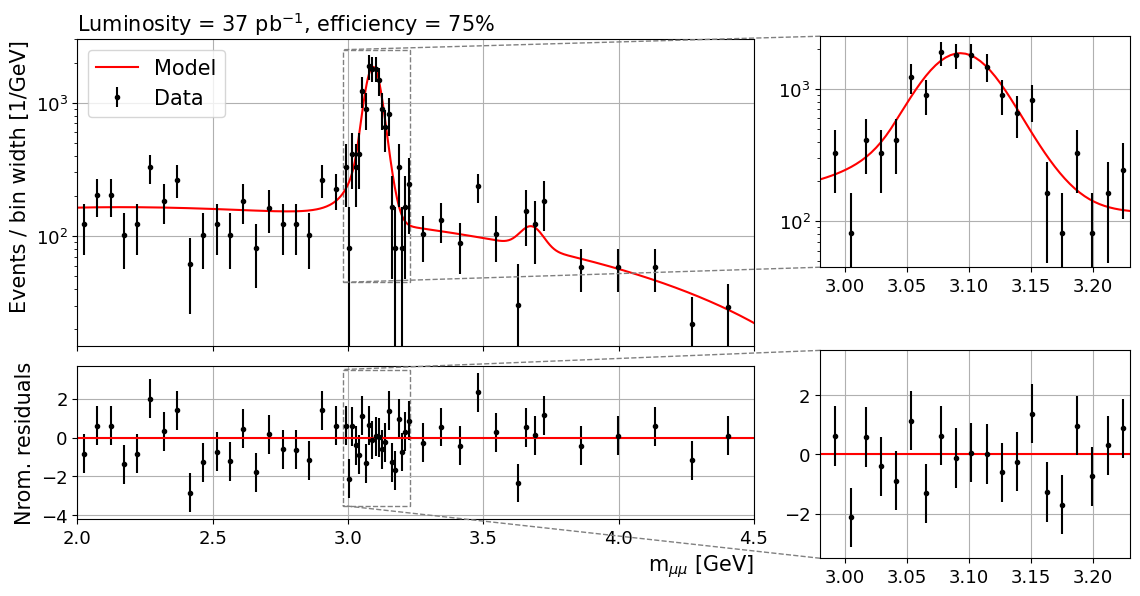

In [10]:
# Plotting only the combined model over the data and the residuals
fig, (ax_plot, ax_res) = plt.subplots(2,1, figsize=(8,6), sharex = True, gridspec_kw={'height_ratios': [2, 1]})
x = np.linspace(2,6,1000)
graph_total_model = total_model.pdf(x)*total_model.get_yield()

#plot the counts divided by bin-size (such that the integral is the total number of events)
ax_plot.plot(x, graph_total_model, label='Model', color = "red")
ax_plot.errorbar(bin_centers_bkg_A, binned_bkg_A/bin_width_bkg_A, yerr=err_binned_bkg_A/bin_width_bkg_A, fmt='.', color = 'black'              )
ax_plot.errorbar(bin_centers_JPsi , binned_JPsi /bin_width_JPsi , yerr=err_binned_JPsi /bin_width_JPsi , fmt='.', color = 'black'              )
ax_plot.errorbar(bin_centers_bkg_B, binned_bkg_B/bin_width_bkg_B, yerr=err_binned_bkg_B/bin_width_bkg_B, fmt='.', color = 'black'              )
ax_plot.errorbar(bin_centers_Psi2s, binned_Psi2s/bin_width_Psi2s, yerr=err_binned_Psi2s/bin_width_Psi2s, fmt='.', color = 'black'              )
ax_plot.errorbar(bin_centers_bkg_C, binned_bkg_C/bin_width_bkg_C, yerr=err_binned_bkg_C/bin_width_bkg_C, fmt='.', color = 'black', label='Data')

ax_zoom = inset_axes(ax_plot, width="50%", height="50%", loc='upper right', bbox_to_anchor=(0.7, 0.08, 1, 1), bbox_transform=ax.transAxes)
ax_zoom.plot(x, graph_total_model, label='Model', color = "red")
ax_zoom.errorbar(bin_centers_bkg_A, binned_bkg_A/bin_width_bkg_A, yerr=err_binned_bkg_A/bin_width_bkg_A, fmt='.', color = 'black'              )
ax_zoom.errorbar(bin_centers_JPsi , binned_JPsi /bin_width_JPsi , yerr=err_binned_JPsi /bin_width_JPsi , fmt='.', color = 'black'              )
ax_zoom.errorbar(bin_centers_bkg_B, binned_bkg_B/bin_width_bkg_B, yerr=err_binned_bkg_B/bin_width_bkg_B, fmt='.', color = 'black'              )
ax_zoom.errorbar(bin_centers_Psi2s, binned_Psi2s/bin_width_Psi2s, yerr=err_binned_Psi2s/bin_width_Psi2s, fmt='.', color = 'black'              )
ax_zoom.errorbar(bin_centers_bkg_C, binned_bkg_C/bin_width_bkg_C, yerr=err_binned_bkg_C/bin_width_bkg_C, fmt='.', color = 'black', label='Data')
x_box = [2.98,3.23]
y_box = [45,2.5e3]
ax_zoom.set_xlim(x_box)
ax_zoom.set_ylim(y_box)
ax_zoom.yaxis.set_major_formatter(ScalarFormatter())
ax_zoom.yaxis.get_major_formatter().set_scientific(True)
ax_zoom.yaxis.get_major_formatter().set_powerlimits((0, 0))
ax_zoom.tick_params(axis='both', labelsize=tfs)
ax_zoom.grid()
ax_zoom.set_yscale('log')
mark_inset(ax_plot, ax_zoom, loc1=2, loc2=3, fc="none", ec="0.5", linestyle='--')

ax_plot.set_xlim([2,mass_cut_LS])
ax_plot.set_ylim([15,3e3])
ax_plot.set_ylabel(f"Events / bin width [1/GeV]", fontsize=fs, loc='top')
ax_plot.set_title("Luminosity = 37 pb$^{-1}$, efficiency = 75%", loc = "left", fontsize = fs)
ax_plot.legend(fontsize = fs, loc='upper left')
ax_plot.tick_params(axis='both', labelsize=tfs)
ax_plot.grid()
ax_plot.set_yscale('log')

#plot the residuals
residuals_bkg_A = (binned_bkg_A/bin_width_bkg_A - total_model.pdf(bin_centers_bkg_A)*total_model.get_yield())/(err_binned_bkg_A/bin_width_bkg_A) 
residuals_JPsi  = (binned_JPsi /bin_width_JPsi  - total_model.pdf(bin_centers_JPsi )*total_model.get_yield())/(err_binned_JPsi /bin_width_JPsi ) 
residuals_bkg_B = (binned_bkg_B/bin_width_bkg_B - total_model.pdf(bin_centers_bkg_B)*total_model.get_yield())/(err_binned_bkg_B/bin_width_bkg_B) 
residuals_Psi2s = (binned_Psi2s/bin_width_Psi2s - total_model.pdf(bin_centers_Psi2s)*total_model.get_yield())/(err_binned_Psi2s/bin_width_Psi2s) 
residuals_bkg_C = (binned_bkg_C/bin_width_bkg_C - total_model.pdf(bin_centers_bkg_C)*total_model.get_yield())/(err_binned_bkg_C/bin_width_bkg_C) 
ax_res.errorbar(bin_centers_bkg_A, residuals_bkg_A, yerr=1, fmt='.', color = 'black')
ax_res.errorbar(bin_centers_JPsi , residuals_JPsi , yerr=1, fmt='.', color = 'black')
ax_res.errorbar(bin_centers_bkg_B, residuals_bkg_B, yerr=1, fmt='.', color = 'black')
ax_res.errorbar(bin_centers_Psi2s, residuals_Psi2s, yerr=1, fmt='.', color = 'black')
ax_res.errorbar(bin_centers_bkg_C, residuals_bkg_C, yerr=1, fmt='.', color = 'black')

ax_zoom = inset_axes(ax_res, width="50%", height="45%", loc='upper right', bbox_to_anchor=(0.7, -0.6, 1, 1), bbox_transform=ax.transAxes)
ax_zoom.axhline(0, color = "red")
ax_zoom.errorbar(bin_centers_bkg_A, residuals_bkg_A, yerr=1, fmt='.', color = 'black')
ax_zoom.errorbar(bin_centers_JPsi , residuals_JPsi , yerr=1, fmt='.', color = 'black')
ax_zoom.errorbar(bin_centers_bkg_B, residuals_bkg_B, yerr=1, fmt='.', color = 'black')
ax_zoom.errorbar(bin_centers_Psi2s, residuals_Psi2s, yerr=1, fmt='.', color = 'black')
ax_zoom.errorbar(bin_centers_bkg_C, residuals_bkg_C, yerr=1, fmt='.', color = 'black')
x_box = [2.98,3.23]
y_box = [-3.5,3.5]
ax_zoom.set_xlim(x_box)
ax_zoom.set_ylim(y_box)
ax_zoom.yaxis.set_major_formatter(ScalarFormatter())
ax_zoom.yaxis.get_major_formatter().set_scientific(True)
ax_zoom.yaxis.get_major_formatter().set_powerlimits((0, 0))
ax_zoom.tick_params(axis='both', labelsize=tfs)
ax_zoom.grid()
mark_inset(ax_res, ax_zoom, loc1=2, loc2=3, fc="none", ec="0.5", linestyle='--')

ax_res.axhline(0, color = "red")
ax_res.set_xlim([2,mass_cut_LS])
ax_res.set_xlabel("m$_{\\mu\\mu}$ [GeV]", fontsize = fs, loc='right')
ax_res.set_ylabel("Nrom. residuals", fontsize = fs)
ax_res.tick_params(axis='both', labelsize=tfs)
ax_res.grid()

plt.tight_layout()
plt.savefig("LS_Fit.png", bbox_inches='tight')
plt.show()

### Normalized residuals 

Given a total number of residuals equal to 54, we have found
 - 64.8% residuals in 1 sigma
 - 92.6% residuals in 2 sigma


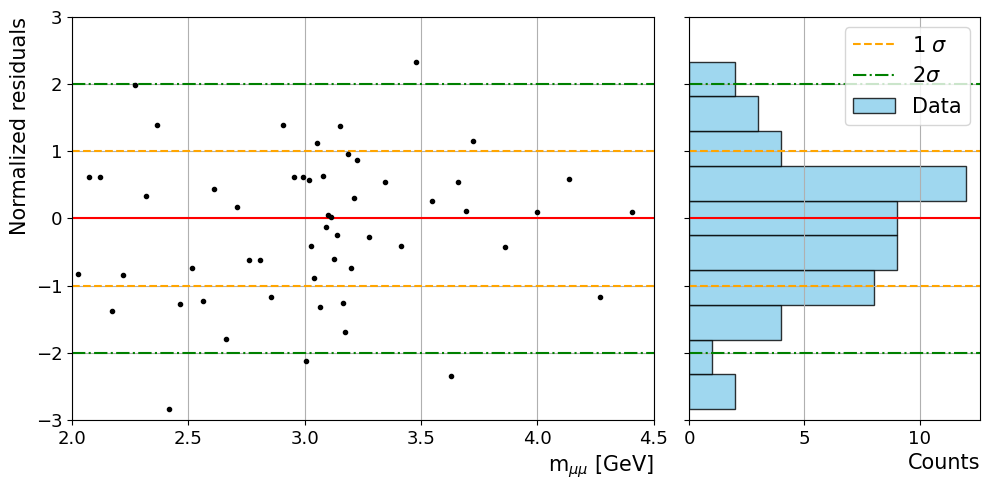

In [31]:
#plot the residuals


#Plot of the residuals
fig, (ax_plot, ax_hist) = plt.subplots(1,2, figsize=(10,5), sharey = True, gridspec_kw={'width_ratios': [2, 1]})

#compute normalized residuals
norm_residuals_bkg_A = residuals_bkg_A #/ (err_binned_bkg_A/bin_width_bkg_A)
norm_residuals_JPsi  = residuals_JPsi  #/ (err_binned_JPsi /bin_width_JPsi)
norm_residuals_bkg_B = residuals_bkg_B #/(err_binned_bkg_B/bin_width_bkg_B)
norm_residuals_Psi2s = residuals_Psi2s #/(err_binned_Psi2s/bin_width_Psi2s)
norm_residuals_bkg_C = residuals_bkg_C #/(err_binned_bkg_C/bin_width_bkg_C)

norm_residuals = np.concatenate((norm_residuals_bkg_A ,norm_residuals_JPsi,norm_residuals_bkg_B,norm_residuals_Psi2s,norm_residuals_bkg_C))

frac_1sigma = len(norm_residuals[np.abs(norm_residuals) <1]) / len(norm_residuals)
frac_2sigma = len(norm_residuals[np.abs(norm_residuals) <2]) / len(norm_residuals)

print(f"Given a total number of residuals equal to {len(norm_residuals)}, we have found")
print(f" - {frac_1sigma*100:.1f}% residuals in 1 sigma")
print(f" - {frac_2sigma*100:.1f}% residuals in 2 sigma")

#First subplot of normalized residuals
ax_plot.axhline(0, color = "red")
ax_plot.axhline(1, color = "orange", linestyle="--", label = "1$\\sigma$")
ax_plot.axhline(-1, color = "orange", linestyle="--")
ax_plot.axhline(2, color = "green", linestyle="-.", label = "2$\\sigma$")
ax_plot.axhline(-2, color = "green", linestyle="-.")

ax_plot.errorbar(bin_centers_bkg_A, norm_residuals_bkg_A, fmt='.', color = 'black')
ax_plot.errorbar(bin_centers_JPsi , norm_residuals_JPsi, fmt='.', color = 'black')
ax_plot.errorbar(bin_centers_bkg_B, norm_residuals_bkg_B, fmt='.', color = 'black')
ax_plot.errorbar(bin_centers_Psi2s, norm_residuals_Psi2s, fmt='.', color = 'black')
ax_plot.errorbar(bin_centers_bkg_C, norm_residuals_bkg_C, fmt='.', color = 'black')

ax_plot.set_xlim([2,mass_cut_LS])
ax_plot.set_ylim([-3,3])
ax_plot.set_ylabel("Normalized residuals",fontsize = fs, loc='top')
ax_plot.set_xlabel("m$_{\\mu\\mu}$ [GeV]", fontsize = fs, loc='right')
ax_plot.tick_params(axis='both', labelsize=tfs)
ax_plot.grid()
#ax_plot.text(2.0,3.2, f'Residuals in 1$\\sigma$: {frac_1sigma * 100:.1f}%\nResiduals in 2$\\sigma$: {frac_2sigma * 100:.1f}%\n$\chi^2$/ndf = {chi2_norm:.2f} (max {chi2_limit:.2f} at 95% SL)', color='black', fontsize = fs)

#histogram of the normalized residuals
ax_hist.axhline(0, color = "red")
ax_hist.axhline(1, color = "orange", linestyle="--", label = "1 $\\sigma$")
ax_hist.axhline(-1, color = "orange", linestyle="--",)
ax_hist.axhline(2, color = "green", linestyle="-.", label = "2$\\sigma$")
ax_hist.axhline(-2, color = "green", linestyle="-.")

ax_hist.hist(norm_residuals, bins=10, orientation='horizontal', color='skyblue', alpha = 0.8, edgecolor='black', label='Data')
ax_hist.set_xlabel("Counts", fontsize = fs, loc='right')
ax_hist.tick_params(axis='both', labelsize=tfs)
ax_hist.grid()
ax_hist.legend(fontsize = fs, loc='upper right')

plt.tight_layout()

plt.savefig("LS_Residuals.png")
plt.show()

## Run test

In [12]:
# Counting how many adiacent residuals have the same sign

runs = [] # Will contain the runs, the number of residuals having the same sign
j    = 1  # It will count the number of residuals of same sign in the current chunk (already starting from the first residual)
for i in range(1, len(norm_residuals)):
    if norm_residuals[i]*norm_residuals[i-1] > 0: # This happens when they have the same sign
        j+=1
    else:
        runs.append(j)
        j = 1
runs.append(j) # To include the final run

In [13]:
# Counting the positive and negative residuals

N_pos = len(norm_residuals[norm_residuals>0])
N_neg = len(norm_residuals[norm_residuals<0])

print(f"Number of positive residuals: {N_pos}")
print(f"Number of negative residuals: {N_neg}")

# Evaluating the expected average number of runs and its variance
# Formulae taken from James, "Statistical methods in Experimental Physics" pg 309

mean_runs_number = 1 + 2*N_pos*N_neg/(N_pos+N_neg)
var_runs_number  = 2*N_pos*N_neg*(2*N_pos*N_neg-N_pos-N_neg)/(N_pos+N_neg)**2/(N_pos+N_neg-1)

# Comparing our value with the expected one

print(f"Measured number of runs: {len(runs)}")
print(f"Expected number of runs: {mean_runs_number:.1f} with std = {np.sqrt(var_runs_number):.1f}")

Number of positive residuals: 28
Number of negative residuals: 26
Measured number of runs: 34
Expected number of runs: 28.0 with std = 3.6


In [14]:
#probability function of runs
R = range(2, 2*min(N_pos, N_neg) + 1)

runs_pdf = []
for r in R:
    if r%2 == 0: # This happens if r is even
        s = int(r/2)
        runs_pdf.append( 2*math.comb(N_pos-1, s-1)*math.comb(N_neg-1,s-1)/math.comb(N_pos+N_neg,N_pos) )
    else:
        s = int((r+1)/2)
        runs_pdf.append( (math.comb(N_pos-1, s-2)*math.comb(N_neg-1,s-1) + math.comb(N_pos-1, s-1)*math.comb(N_neg-1,s-2))/math.comb(N_pos+N_neg,N_pos) )

print(f"Normalization: {sum(runs_pdf)}")

Normalization: 0.9999999999999855


In [15]:
#Defining the rejection interval
CDF = np.cumsum(runs_pdf)
alpha = 0.05
significance_level = 1-alpha
quantile = R[np.searchsorted(CDF, alpha, side = 'left')]
print(f"Integrating up to R = {R[np.searchsorted(CDF, alpha, side = 'left')]-1}: cumulative = {CDF[np.searchsorted(CDF, alpha)-1]:.3f}")
print(f"Given a significance level of {significance_level}, the critical region is R < R_min = {quantile}")

Integrating up to R = 21: cumulative = 0.037
Given a significance level of 0.95, the critical region is R < R_min = 22


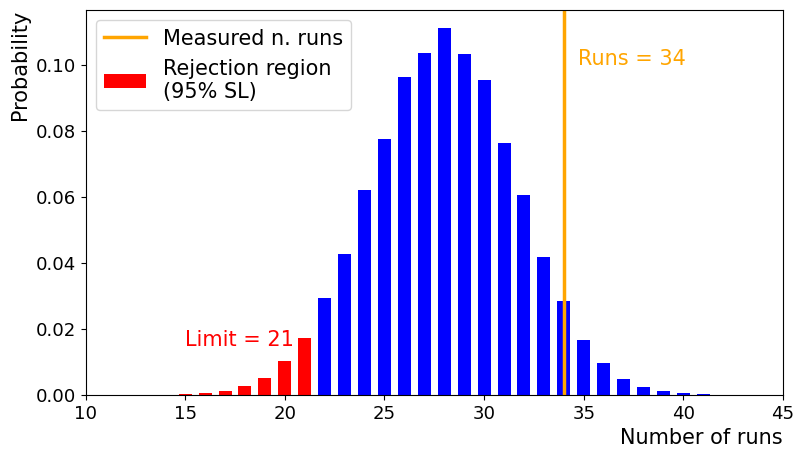

In [32]:
# Plotting the probability distribution of the runs number and Hypothesis Testing
plt.figure(figsize = (9,5))
plt.bar(R[np.searchsorted(CDF, alpha, side = 'left'):], runs_pdf[np.searchsorted(CDF, alpha, side = 'left'):], width = 0.65, color = 'b')
plt.bar(R[0:np.searchsorted(CDF, alpha, side = 'left')], runs_pdf[0:np.searchsorted(CDF, alpha, side = 'left')], width = 0.65, color = 'r', label = "Rejection region\n(95% SL)")
plt.axvline(len(runs), color='orange',linewidth = "2.5", label = "Measured n. runs")

plt.xlim([10,45])
plt.legend(fontsize = fs)
#plt.title("Run test", fontsize = fs)
plt.ylabel("Probability", fontsize = fs, loc='top')
plt.xlabel("Number of runs", fontsize = fs, loc='right')
plt.text(len(runs)+0.7, 0.1, f"Runs = {len(runs)}", fontsize = fs, color = "orange")
plt.text(R[np.searchsorted(CDF, alpha, side = 'left')] - 7, 0.015, f"Limit = {R[np.searchsorted(CDF, alpha, side = 'left')]-1}", fontsize = fs, color = "red")
plt.tick_params(axis='both', labelsize=tfs)

plt.savefig("LS_Runs_distribution.png")
plt.show()

## Setting upper limit

In [10]:
# (1) Defining the bkg only hypothesis
bkg_only_hypothesis = POI(xs_psi2s, 0)

#(2)
calculator_low_sig = AsymptoticCalculator(input=result, minimizer=minimizer)
discovery_low_sig = Discovery(calculator=calculator_low_sig, poinull=bkg_only_hypothesis)
discovery_low_sig.result()

(np.float64(0.1713145916330896), np.float64(0.9489831476475641))

In [11]:
# Range of xs_psi2s values to scan.
xs_psi2s_scan = POIarray(xs_psi2s, np.linspace(0, 40, 40))
ul = UpperLimit(calculator=calculator_low_sig, poinull=xs_psi2s_scan, poialt=bkg_only_hypothesis)

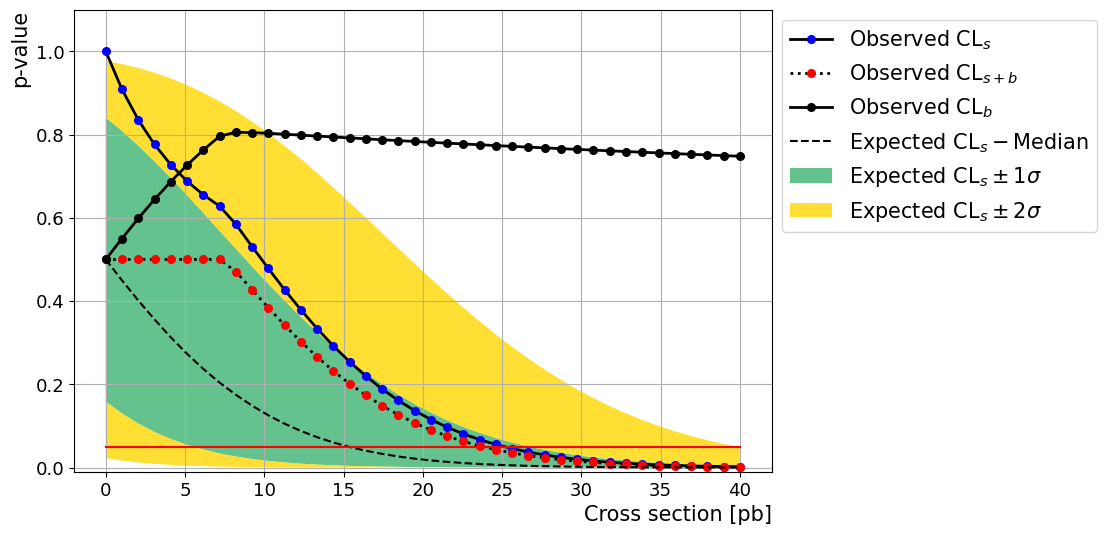

In [18]:
fig = plt.figure(figsize = (9,6))
plt.grid()
ax = plotlimit_uncorrected_observed(ul, CLs=False)
plt.legend(fontsize = fs, loc='upper left', bbox_to_anchor=(1, 1))
plt.ylabel("p-value", fontsize=fs, loc='top')
plt.xlabel("Cross section [pb]", fontsize=fs, loc='right')
plt.tick_params(axis='both', labelsize=tfs)

# Define zoom region in main plot
inset_ax = fig.add_axes([0.91, 0.11, 0.33, 0.345])
x = np.linspace(0,5, 1000)
q_mu_mu = np.exp(-x)/(1-np.exp(-5))/2 #+ 0.5*(x==0)
q_mu_0  =1/np.sqrt(2*np.pi)*np.exp(-(x-2.2)**2)
inset_ax.plot(x, q_mu_mu, color='#5DA9CE')
inset_ax.plot(x, q_mu_0 , color='#FFA45B')
vertical_line_position = x[np.argmax(q_mu_0)]-0.8
color = 'red'
con = ConnectionPatch(xyA=(vertical_line_position, 0.5), coordsA=inset_ax.transData, #1/np.sqrt(2*np.pi)*np.exp(-(vertical_line_position-2.2)**2)), coordsA=inset_ax.transData,
                      xyB=(vertical_line_position, 0), coordsB=inset_ax.transData,
                      color='red', linestyle='--')
inset_ax.add_artist(con)
inset_ax.fill_between(x[x>vertical_line_position], q_mu_mu[x>vertical_line_position], alpha=0.5, facecolor=color, hatch='//', edgecolor=color, linewidth=0.0)


x1 = 12.5
y1, y2 = 0, 1
inset_ax.tick_params(axis='both', labelsize=tfs)
inset_ax.yaxis.tick_right()
inset_ax.yaxis.set_label_position("right")
inset_ax.set_title("PDF", fontsize=fs, loc='right')
inset_ax.set_xlabel("q$_{\mu}$", fontsize=fs, loc='right')
inset_ax.tick_params(axis='y', labelrotation=90)
for label in inset_ax.get_yticklabels():
    label.set_ha('left')
    label.set_va('bottom')
inset_ax.grid()
coords_main = [(x1, y1), (x1, y2),]
coords_inset = [
    (inset_ax.get_xlim()[0], inset_ax.get_ylim()[0]),
    (inset_ax.get_xlim()[0], inset_ax.get_ylim()[1]),
]
for (xm, ym), (xi, yi) in zip(coords_main, coords_inset):
    con = ConnectionPatch(xyA=(xi, yi), coordsA=inset_ax.transData,
                          xyB=(xm, ym), coordsB=ax.transData,
                          color='gray', linestyle='dashed')
    inset_ax.add_artist(con)
con = ConnectionPatch(xyA=(x1, y1), coordsA=ax.transData,
                      xyB=(x1, y2), coordsB=ax.transData,
                      color='gray', linestyle='dashed')
inset_ax.add_artist(con)
inset_ax.text(0.2,0.45,'f(q$_\mu|\mu$)', fontsize=tfs, color='#5DA9CE')
inset_ax.text(2.1,0.42, 'f(q$_\mu|0$)', fontsize=tfs, color='#FFA45B')
inset_ax.text(1.45,0.48, 'Observed q$_\mu$', fontsize=tfs, color='red')




plt.savefig("LS_upperlimit_uncorrected_observed.png", bbox_inches='tight')
plt.show()

In [13]:
#upper limit
ul.upperlimit(alpha=0.05)

{'observed': 25.16075118756502,
 'expected': 18.75403462251361,
 'expected_p1': 27.75686378410255,
 'expected_m1': 12.904776965146935,
 'expected_p2': 39.97770974636217,
 'expected_m2': 9.325140341604362}